In [1]:
# Importar librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
import warnings
warnings.filterwarnings('ignore')

# Configurar estilo de gráficos
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')

# Análisis Exploratorio de Datos (EDA) para Detección de Anomalías en Logs de LLM

Este notebook realiza un análisis exhaustivo de los logs de SAP LLM para identificar las columnas más importantes para la detección de anomalías en el sistema de Security Operations Center (SOC).

## Objetivos:
- Explorar la estructura y características de los datos de logs
- Identificar patrones y distribuciones de variables clave
- Detectar anomalías usando técnicas estadísticas y de machine learning
- Determinar la importancia relativa de cada columna para análisis de anomalías
- Proporcionar recomendaciones para implementación de sistema de monitoreo

## Dataset:
- **Fuente**: `raw_logs.json` (2000 registros de logs SAP)
- **Alcance**: Enfoque en logs de tipo LLM_REQUEST (560 registros)
- **Variables clave**: tiempos de respuesta, tamaños, tokens, costos, metadatos regionales

In [13]:
# Cargar datos desde raw_logs.json
import json

with open('../shared_data/raw_logs.json', 'r') as f:
    data = json.load(f)

df = pd.DataFrame(data)
print(f"Dataset shape: {df.shape}")
print(f"Columnas disponibles: {list(df.columns)}")
df.head()

Dataset shape: (2000, 44)
Columnas disponibles: ['_id', '_ignored', '_index', '_score', '@timestamp', '@version', 'event_code_version', 'event_hash', '@event_time_requested', 'headers_content_type', 'headers_http_host', 'headers_http_request_method', 'heathers_request_path', 'sap_function_application', 'sap_source_type', 'sap_function_log_type', 'sap_function_message', 'sap_app_env', 'sap_llm_response_size', 'sap_llm_response_time', 'region_id', 'region_name', 'region_code', 'macro_region', 'service_id', 'http_status_code', 'client_ip', 'llm_model_id', 'llm_provider', 'llm_prompt_id', 'llm_prompt_category', 'llm_prompt', 'llm_prompt_tokens', 'llm_completion_tokens', 'llm_total_tokens', 'llm_response_time_ms', 'llm_response_size_bytes', 'llm_status', 'llm_error_message', 'llm_cost_usd', 'llm_temperature', 'llm_top_p', 'llm_stream', 'llm_finish_reason']


,_id,_ignored,_index,_score,@timestamp,@version,event_code_version,event_hash,@event_time_requested,headers_content_type,...,llm_total_tokens,llm_response_time_ms,llm_response_size_bytes,llm_status,llm_error_message,llm_cost_usd,llm_temperature,llm_top_p,llm_stream,llm_finish_reason
0,f34b8a30-df0a-45c1-badf-452a34262c81,,llm-logs-2026.04,0.526,2026-04-21T06:00:00.000Z,1,3.9.2,75887362b316a642ac7720784a3918e053d28e9e34ba2d...,2026-04-21T05:59:58.107Z,application/x-www-form-urlencoded,...,1210,4210.92,3422,success,,0.00726,1.15,0.72,True,stop
1,50ed3f1c-9e71-4187-b190-3207a46e943a,,sap-logs-2026.04,0.5579,2026-04-21T06:00:00.000Z,1,3.4.1,84054e56e7f4cdffc84965c75ca2b84f8c67e7dc058d45...,2026-04-21T05:59:59.636Z,application/xml,...,,,,,,,,,,
2,4740f4c7-ecfd-4866-beb0-4ca603dcbdef,,llm-logs-2026.04,0.6278,2026-04-21T06:00:00.000Z,1,2.1.1,a120ea4a57b87aae0bb11800e01f2ab28ca81e07b26762...,2026-04-21T05:59:58.835Z,text/plain,...,1038,7566.6,27407,success,,0.000363,0.8,0.65,False,stop
3,a1760a22-68c6-4c62-bd21-a7216f2d9f49,,sap-logs-2026.04,0.7169,2026-04-21T06:00:00.000Z,1,1.9.4,6db769494e11b4be2fe2ff327b69a54009b868926e4485...,2026-04-21T05:59:59.530Z,application/x-www-form-urlencoded,...,,,,,,,,,,
4,0d5f8b9b-aa34-4c17-809e-9ca0d5a7f895,,sap-logs-2026.04,0.7513,2026-04-21T06:00:00.000Z,1,3.2.3,652ad88a149d53e56b1b7cf681e8cb06572cf3f5f14d16...,2026-04-21T05:59:59.966Z,application/json,...,,,,,,,,,,


In [4]:
# Exploración inicial de datos
print("Información general del dataset:")
print(df.info())

print("\nEstadísticas descriptivas para columnas numéricas:")
# Intentar convertir columnas que deberían ser numéricas
potential_numeric_cols = ['_score', 'sap_llm_response_size', 'sap_llm_response_time', 
                         'llm_prompt_tokens', 'llm_completion_tokens', 'llm_total_tokens', 
                         'llm_response_time_ms', 'llm_response_size_bytes', 'llm_cost_usd', 
                         'llm_temperature', 'llm_top_p']

for col in potential_numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

numeric_cols = df.select_dtypes(include=[np.number]).columns
if len(numeric_cols) > 0:
    print(df[numeric_cols].describe())
else:
    print("No se encontraron columnas numéricas.")

print("\nValores únicos por columna categórica:")
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols[:10]:  # Mostrar solo las primeras 10
    print(f"{col}: {df[col].nunique()} valores únicos")

print("\nValores nulos por columna:")
print(df.isnull().sum())

Información general del dataset:
<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 44 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   _id                          2000 non-null   str  
 1   _ignored                     2000 non-null   str  
 2   _index                       2000 non-null   str  
 3   _score                       2000 non-null   str  
 4   @timestamp                   2000 non-null   str  
 5   @version                     2000 non-null   str  
 6   event_code_version           2000 non-null   str  
 7   event_hash                   2000 non-null   str  
 8   @event_time_requested        2000 non-null   str  
 9   headers_content_type         2000 non-null   str  
 10  headers_http_host            2000 non-null   str  
 11  headers_http_request_method  2000 non-null   str  
 12  heathers_request_path        2000 non-null   str  
 13  sap_function_application  

In [5]:
# Limpieza y preparación de datos
# Convertir timestamps a datetime
df['@timestamp'] = pd.to_datetime(df['@timestamp'])
df['@event_time_requested'] = pd.to_datetime(df['@event_time_requested'])

# Convertir columnas numéricas que están como string
numeric_string_cols = ['sap_llm_response_time', 'sap_llm_response_size', 'llm_prompt_tokens', 
                      'llm_completion_tokens', 'llm_total_tokens', 'llm_response_time_ms', 
                      'llm_response_size_bytes', 'llm_cost_usd', 'llm_temperature', 'llm_top_p']

for col in numeric_string_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Crear columna de duración de respuesta (si no existe)
if 'sap_llm_response_time' in df.columns:
    df['response_time_sec'] = df['sap_llm_response_time'] / 1000

# Filtrar solo logs de LLM para análisis de anomalías
llm_logs = df[df['sap_function_log_type'] == 'LLM_REQUEST'].copy()

print(f"Logs de LLM: {llm_logs.shape[0]} registros")
print(f"Columnas numéricas relevantes: {numeric_string_cols}")

Logs de LLM: 560 registros
Columnas numéricas relevantes: ['sap_llm_response_time', 'sap_llm_response_size', 'llm_prompt_tokens', 'llm_completion_tokens', 'llm_total_tokens', 'llm_response_time_ms', 'llm_response_size_bytes', 'llm_cost_usd', 'llm_temperature', 'llm_top_p']


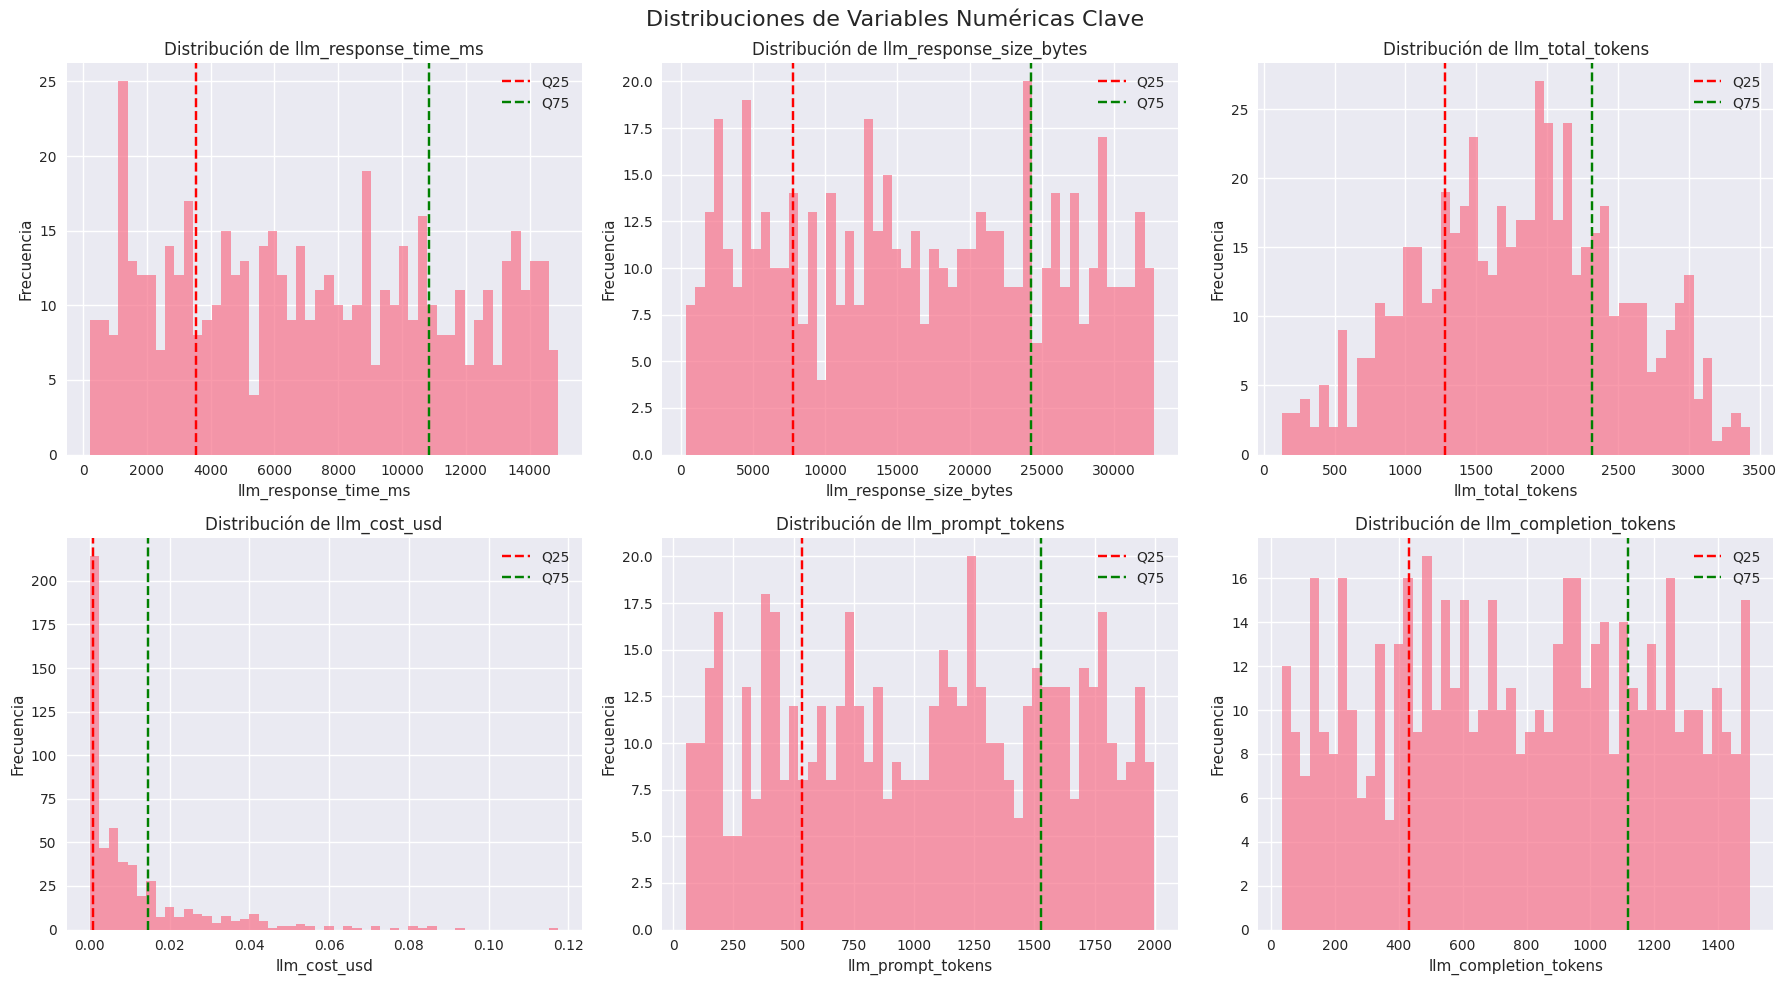

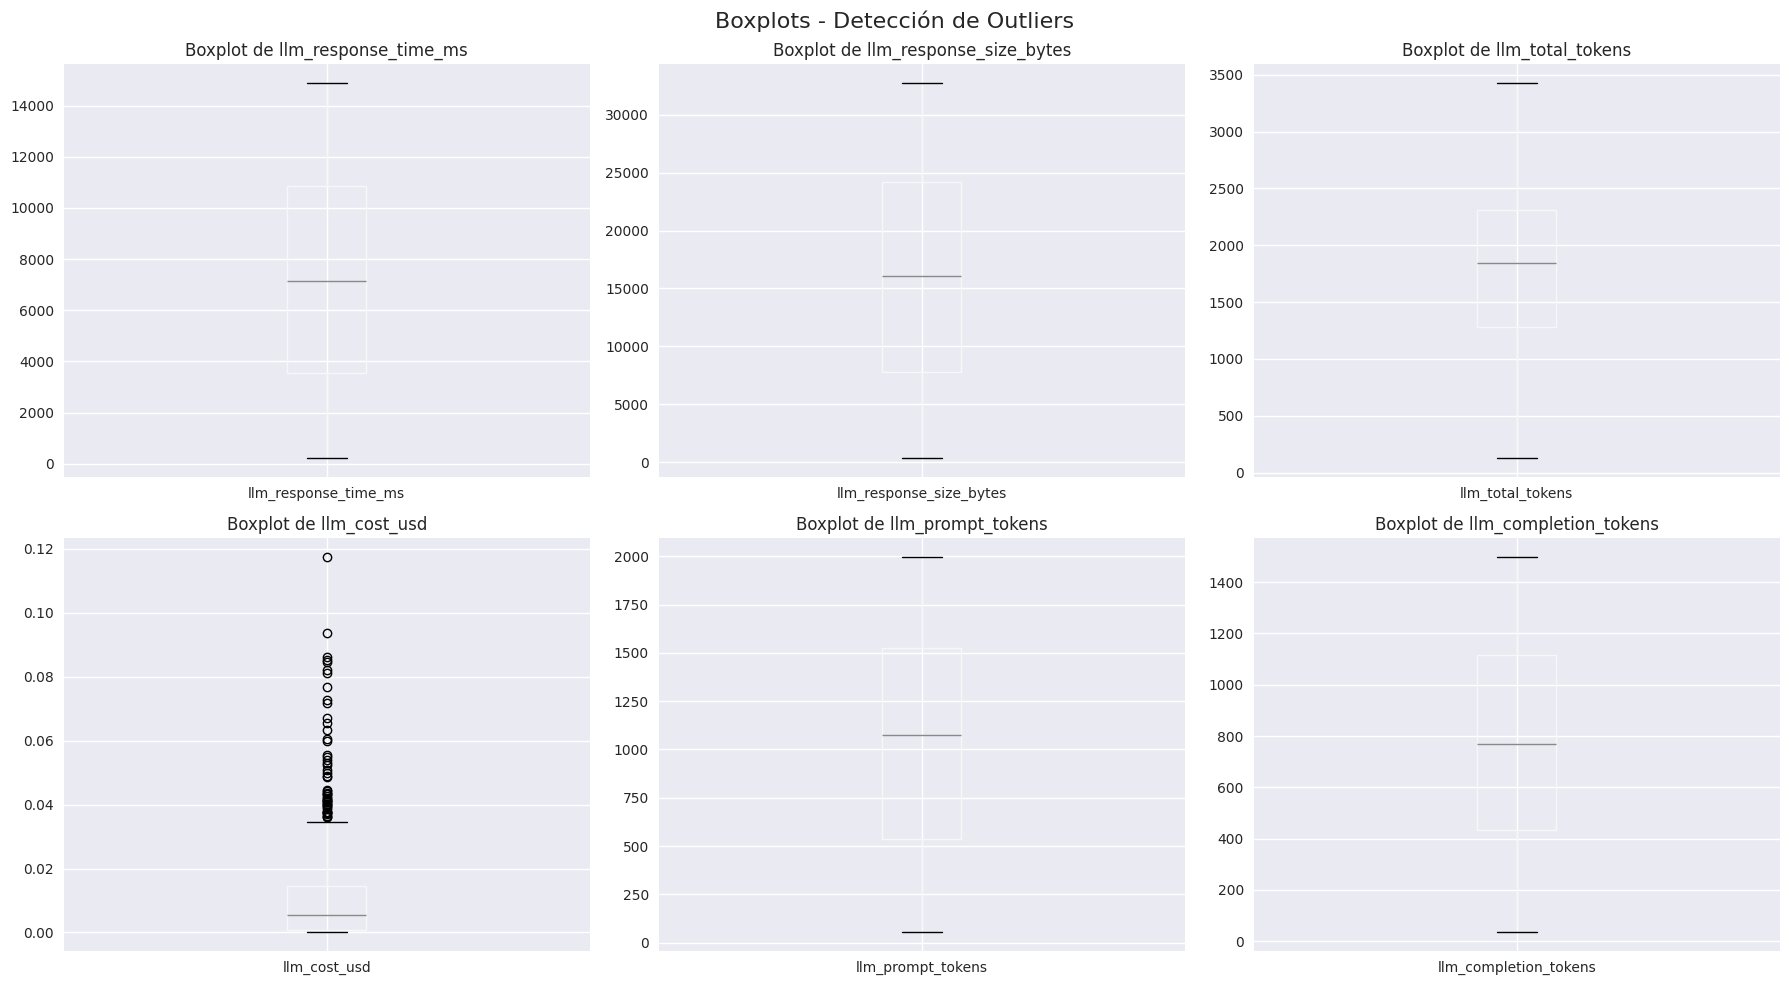

In [6]:
# Análisis univariado de variables numéricas clave
key_numeric_cols = ['llm_response_time_ms', 'llm_response_size_bytes', 'llm_total_tokens', 
                   'llm_cost_usd', 'llm_prompt_tokens', 'llm_completion_tokens']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Distribuciones de Variables Numéricas Clave', fontsize=16)

for i, col in enumerate(key_numeric_cols):
    if col in llm_logs.columns:
        ax = axes[i//3, i%3]
        llm_logs[col].dropna().hist(bins=50, ax=ax, alpha=0.7)
        ax.set_title(f'Distribución de {col}')
        ax.set_xlabel(col)
        ax.set_ylabel('Frecuencia')
        # Agregar líneas de percentiles
        q25, q75 = llm_logs[col].quantile([0.25, 0.75])
        ax.axvline(q25, color='red', linestyle='--', label='Q25')
        ax.axvline(q75, color='green', linestyle='--', label='Q75')
        ax.legend()

plt.tight_layout()
plt.show()

# Boxplots para detectar outliers
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Boxplots - Detección de Outliers', fontsize=16)

for i, col in enumerate(key_numeric_cols):
    if col in llm_logs.columns:
        ax = axes[i//3, i%3]
        llm_logs.boxplot(column=col, ax=ax)
        ax.set_title(f'Boxplot de {col}')

plt.tight_layout()
plt.show()

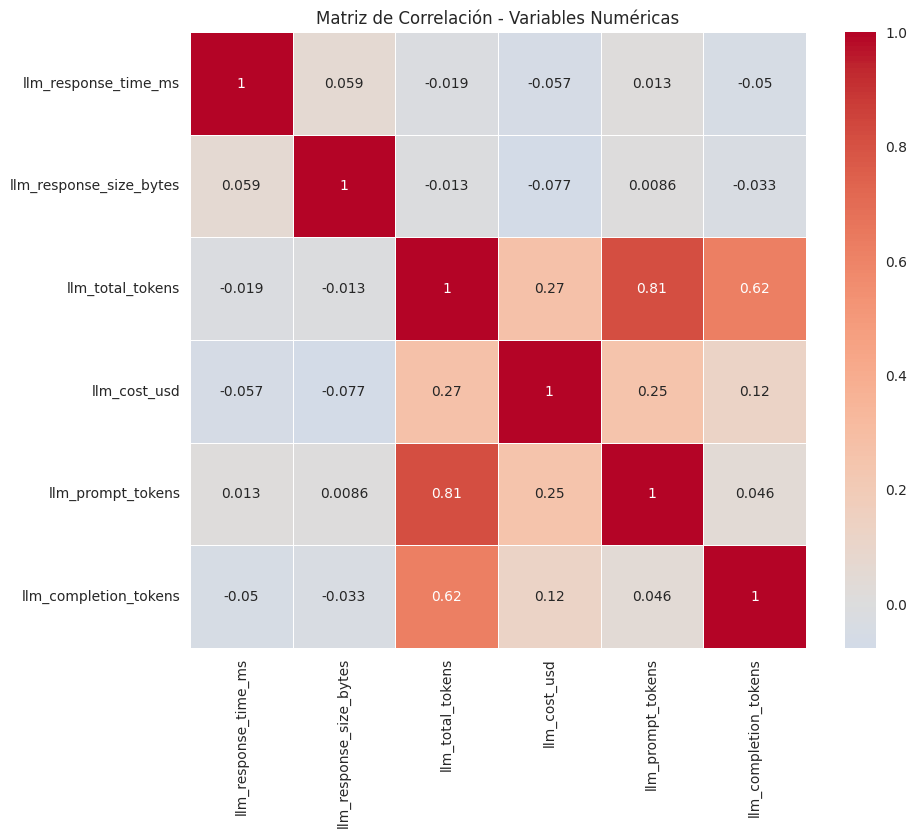

Pares con alta correlación (|corr| > 0.5):
llm_total_tokens vs llm_prompt_tokens: 0.814
llm_total_tokens vs llm_completion_tokens: 0.618


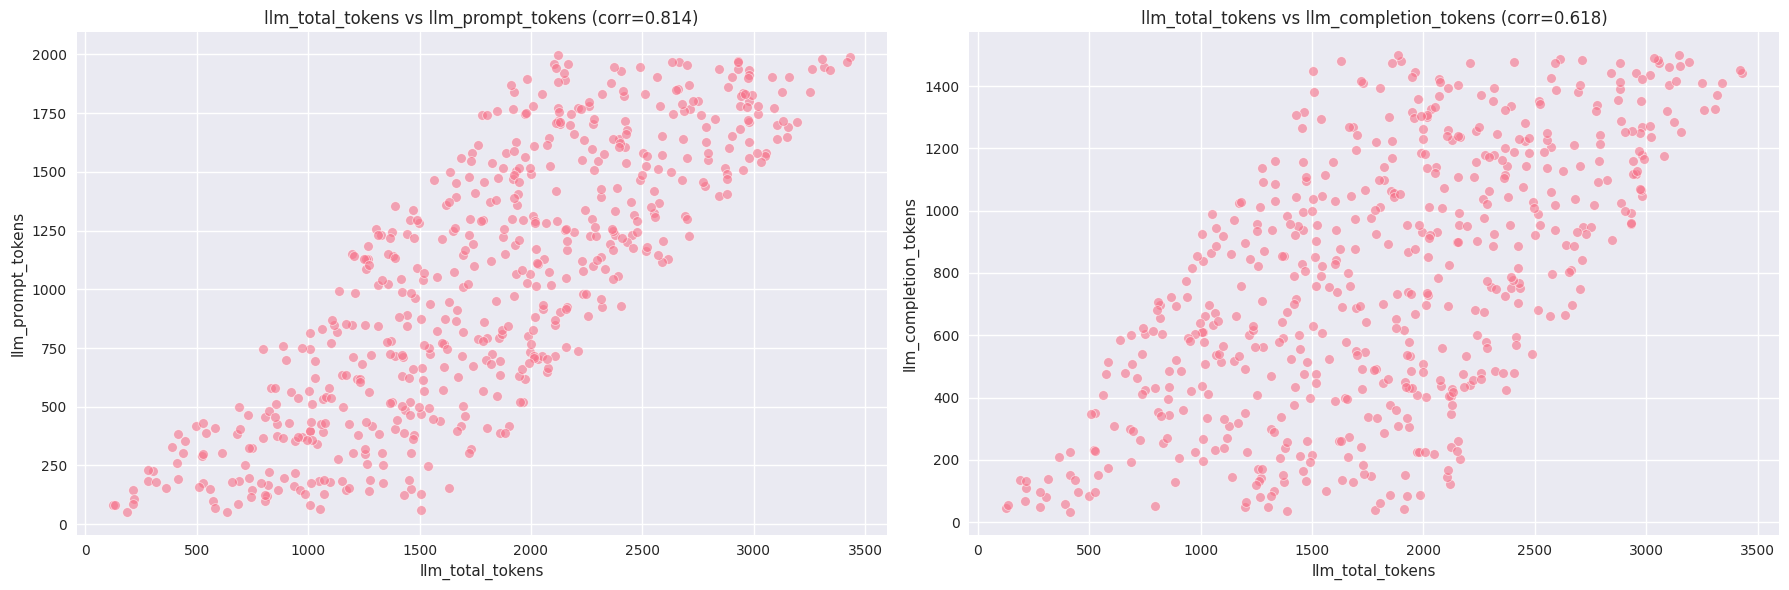

In [7]:
# Análisis de correlaciones
correlation_matrix = llm_logs[key_numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5)
plt.title('Matriz de Correlación - Variables Numéricas')
plt.show()

# Scatter plots de variables altamente correlacionadas
high_corr_pairs = []
for i in range(len(key_numeric_cols)):
    for j in range(i+1, len(key_numeric_cols)):
        corr = correlation_matrix.iloc[i, j]
        if abs(corr) > 0.5:
            high_corr_pairs.append((key_numeric_cols[i], key_numeric_cols[j], corr))

print("Pares con alta correlación (|corr| > 0.5):")
for pair in high_corr_pairs:
    print(f"{pair[0]} vs {pair[1]}: {pair[2]:.3f}")

# Visualizar algunos scatter plots
if high_corr_pairs:
    fig, axes = plt.subplots(1, min(3, len(high_corr_pairs)), figsize=(18, 6))
    if len(high_corr_pairs) == 1:
        axes = [axes]
    
    for i, (col1, col2, corr) in enumerate(high_corr_pairs[:3]):
        ax = axes[i]
        sns.scatterplot(data=llm_logs, x=col1, y=col2, ax=ax, alpha=0.6)
        ax.set_title(f'{col1} vs {col2} (corr={corr:.3f})')
    
    plt.tight_layout()
    plt.show()

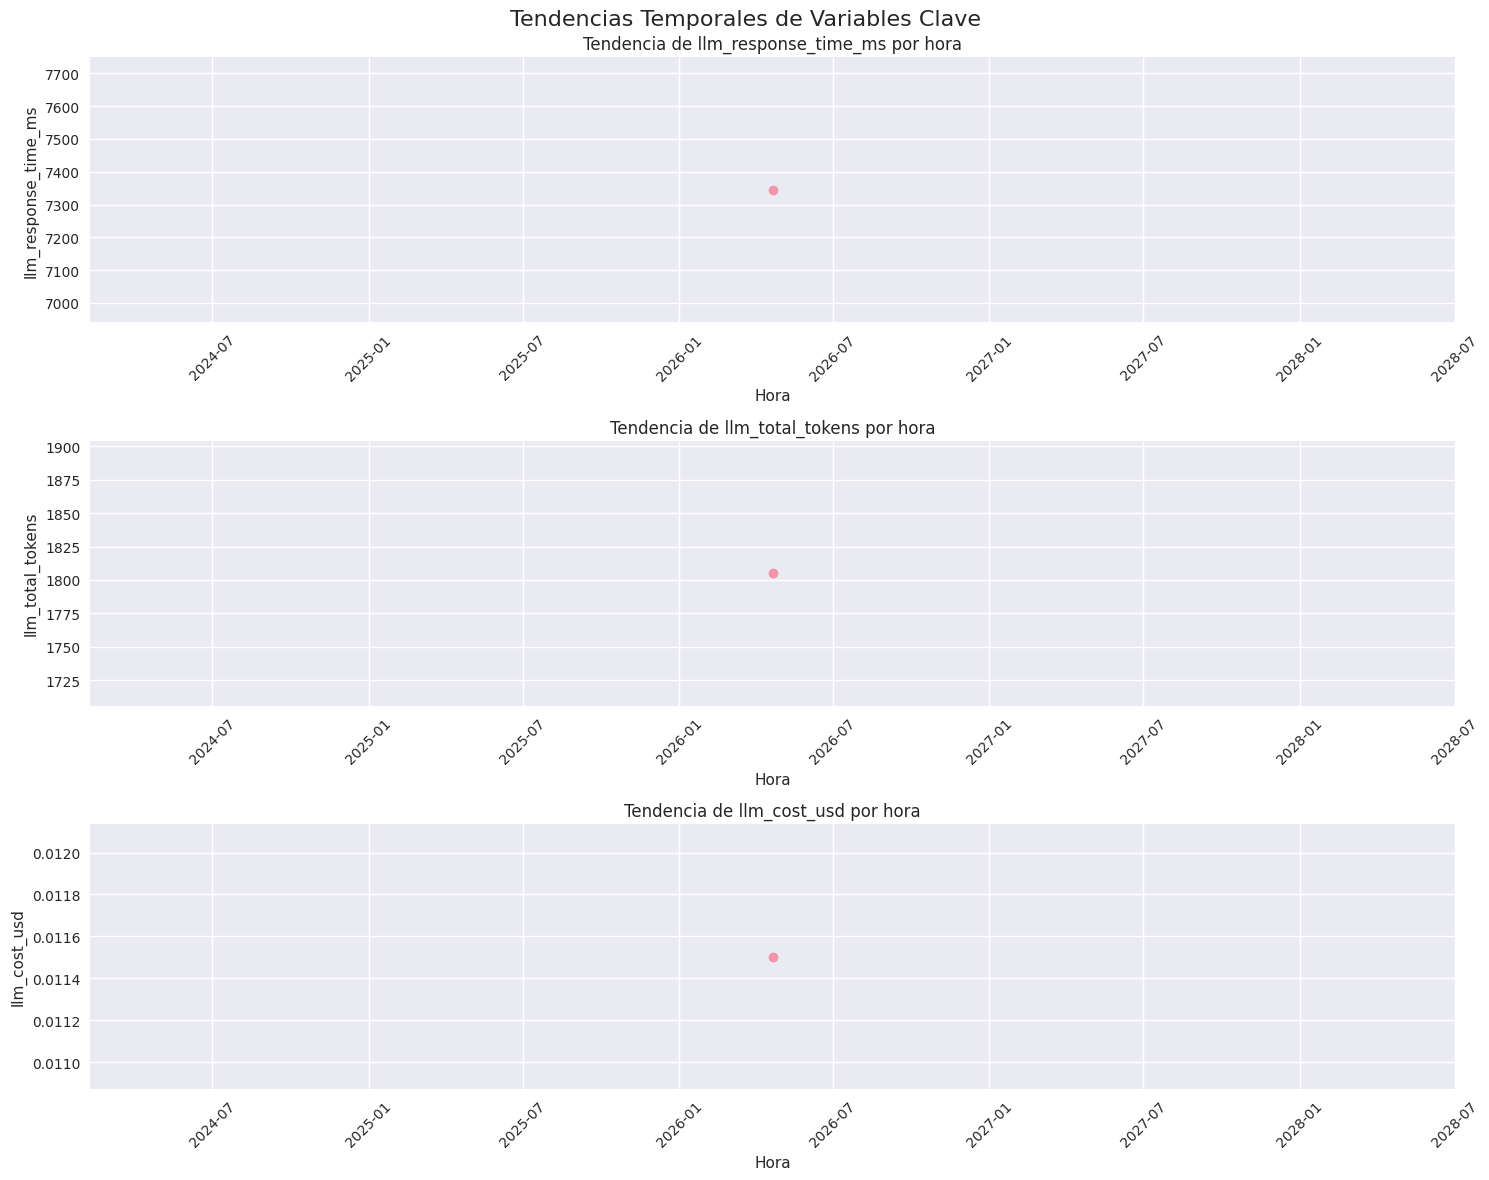

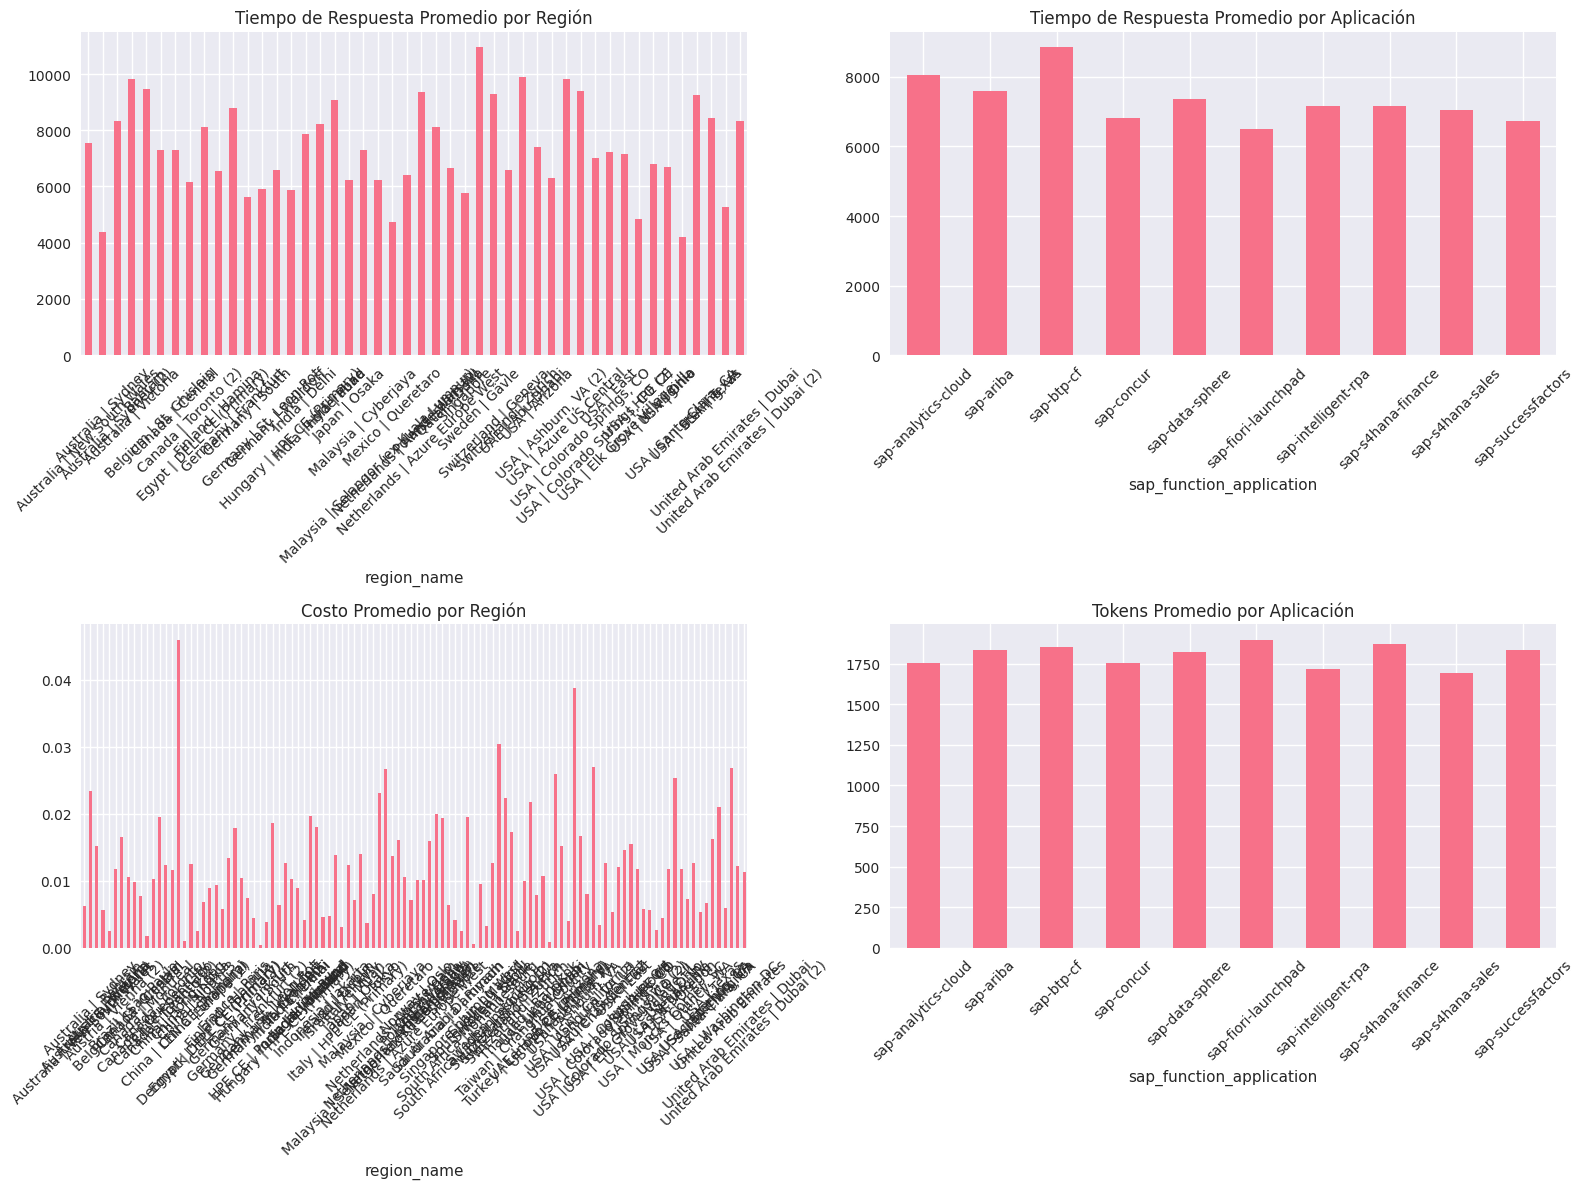

In [9]:
# Análisis temporal
llm_logs['timestamp_hour'] = llm_logs['@timestamp'].dt.floor('h')

# Tendencias temporales
time_series_cols = ['llm_response_time_ms', 'llm_total_tokens', 'llm_cost_usd']

fig, axes = plt.subplots(3, 1, figsize=(15, 12))
fig.suptitle('Tendencias Temporales de Variables Clave', fontsize=16)

for i, col in enumerate(time_series_cols):
    ax = axes[i]
    hourly_data = llm_logs.groupby('timestamp_hour')[col].mean().reset_index()
    ax.plot(hourly_data['timestamp_hour'], hourly_data[col], marker='o', alpha=0.7)
    ax.set_title(f'Tendencia de {col} por hora')
    ax.set_xlabel('Hora')
    ax.set_ylabel(col)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Análisis por región y aplicación
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Response time por región
if 'region_name' in llm_logs.columns:
    region_stats = llm_logs.groupby('region_name')['llm_response_time_ms'].agg(['mean', 'std', 'count'])
    region_stats = region_stats[region_stats['count'] > 5]  # Filtrar regiones con pocos datos
    region_stats['mean'].plot(kind='bar', ax=axes[0,0], title='Tiempo de Respuesta Promedio por Región')
    axes[0,0].tick_params(axis='x', rotation=45)

# Response time por aplicación
if 'sap_function_application' in llm_logs.columns:
    app_stats = llm_logs.groupby('sap_function_application')['llm_response_time_ms'].agg(['mean', 'std', 'count'])
    app_stats = app_stats[app_stats['count'] > 5]
    app_stats['mean'].plot(kind='bar', ax=axes[0,1], title='Tiempo de Respuesta Promedio por Aplicación')
    axes[0,1].tick_params(axis='x', rotation=45)

# Costo por región
if 'region_name' in llm_logs.columns:
    cost_stats = llm_logs.groupby('region_name')['llm_cost_usd'].agg(['mean', 'sum'])
    cost_stats = cost_stats[cost_stats['sum'] > 0]
    cost_stats['mean'].plot(kind='bar', ax=axes[1,0], title='Costo Promedio por Región')
    axes[1,0].tick_params(axis='x', rotation=45)

# Tokens por aplicación
if 'sap_function_application' in llm_logs.columns:
    token_stats = llm_logs.groupby('sap_function_application')['llm_total_tokens'].mean()
    token_stats.plot(kind='bar', ax=axes[1,1], title='Tokens Promedio por Aplicación')
    axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Número de anomalías detectadas: 28 de 560 registros (5.00%)


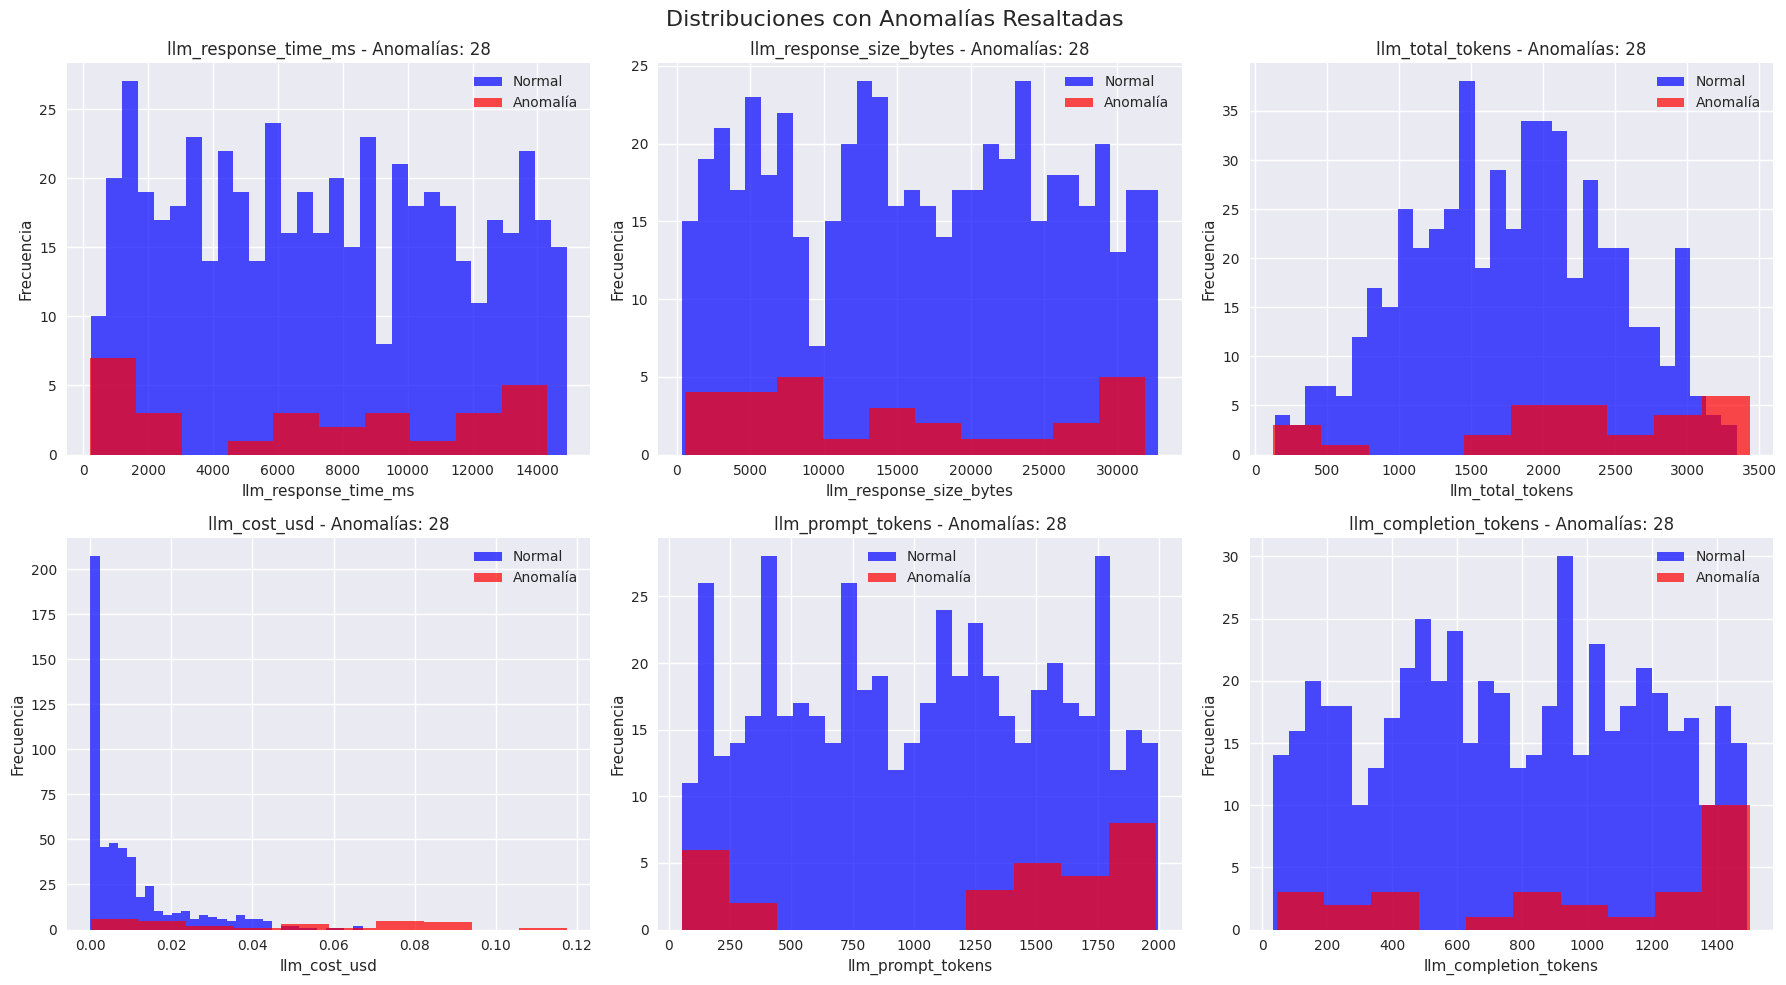


Estadísticas de anomalías detectadas:
       llm_response_time_ms  llm_response_size_bytes  llm_total_tokens  \
count             28.000000                28.000000         28.000000   
mean            7046.218571             14828.892857       2196.071429   
std             4983.201845             10440.387900        987.965584   
min              216.790000               594.000000        127.000000   
25%             1689.687500              5642.750000       1842.750000   
50%             7201.695000             12046.500000       2141.500000   
75%            11714.757500             25460.000000       2965.750000   
max            14306.870000             31848.000000       3431.000000   

       llm_cost_usd  llm_prompt_tokens  llm_completion_tokens  
count     28.000000          28.000000              28.000000  
mean       0.045702        1239.392857             956.678571  
std        0.035097         713.950685             514.696894  
min        0.000152          53.000000

In [ ]:
# Detección de anomalías usando Isolation Forest
# Preparar datos para el modelo
anomaly_features = ['llm_response_time_ms', 'llm_response_size_bytes', 'llm_total_tokens', 
                   'llm_cost_usd', 'llm_prompt_tokens', 'llm_completion_tokens']

# Eliminar filas con NaN
anomaly_data = llm_logs[anomaly_features].dropna()

# Escalar los datos
scaler = StandardScaler()
anomaly_data_scaled = scaler.fit_transform(anomaly_data)

# Aplicar Isolation Forest
iso_forest = IsolationForest(contamination=0.05, random_state=42)
anomaly_predictions = iso_forest.fit_predict(anomaly_data_scaled)

# Agregar resultados al dataframe
anomaly_data['anomaly_score'] = iso_forest.decision_function(anomaly_data_scaled)
anomaly_data['is_anomaly'] = anomaly_predictions

# Contar anomalías
n_anomalies = (anomaly_predictions == -1).sum()
print(f"Número de anomalías detectadas: {n_anomalies} de {len(anomaly_data)} registros ({n_anomalies/len(anomaly_data)*100:.2f}%)")

# Visualizar anomalías
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Distribuciones con Anomalías Resaltadas', fontsize=16)

for i, col in enumerate(anomaly_features):
    ax = axes[i//3, i%3]
    normal_data = anomaly_data[anomaly_data['is_anomaly'] == 1][col]
    anomaly_points = anomaly_data[anomaly_data['is_anomaly'] == -1][col]
    
    ax.hist(normal_data, bins=30, alpha=0.7, label='Normal', color='blue')
    ax.hist(anomaly_points, bins=10, alpha=0.7, label='Anomalía', color='red')
    ax.set_title(f'{col} - Anomalías: {len(anomaly_points)}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frecuencia')
    ax.legend()

plt.tight_layout()
plt.show()

# Mostrar estadísticas de anomalías
print("\nEstadísticas de anomalías detectadas:")
anomaly_stats = anomaly_data[anomaly_data['is_anomaly'] == -1][anomaly_features].describe()
print(anomaly_stats)

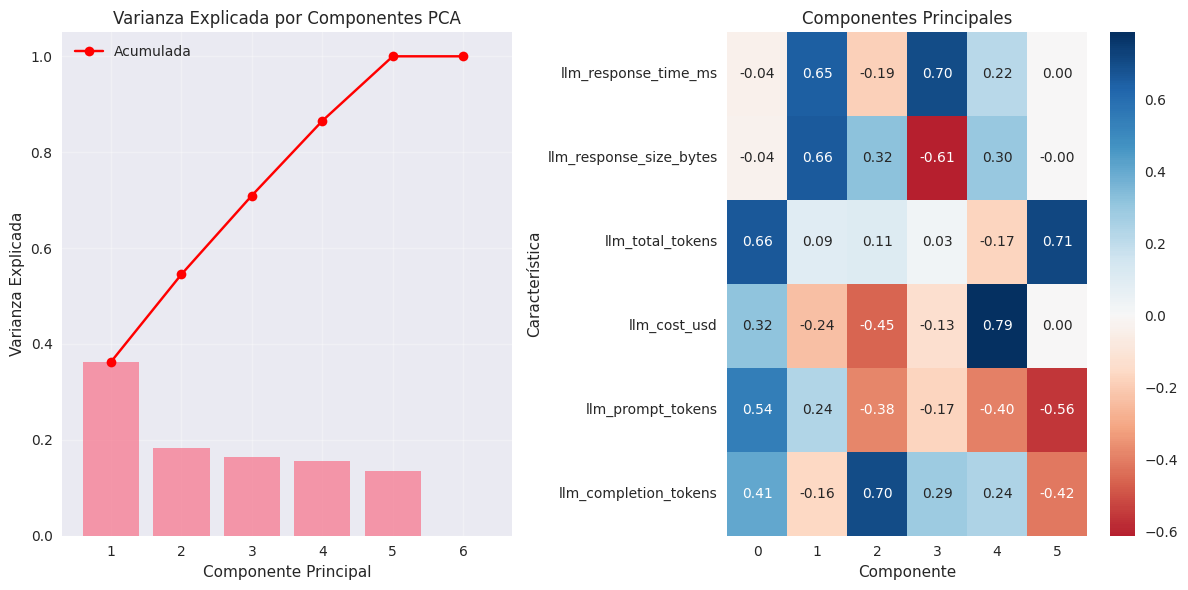


Varianza de cada característica (orden descendente):
llm_response_size_bytes    8.804784e+07
llm_response_time_ms       1.801659e+07
llm_total_tokens           5.063183e+05
llm_prompt_tokens          3.138987e+05
llm_completion_tokens      1.711989e+05
llm_cost_usd               2.694992e-04
dtype: float64

Coeficientes de la primera componente principal:
llm_total_tokens           0.662571
llm_prompt_tokens          0.541933
llm_completion_tokens      0.405626
llm_cost_usd               0.315970
llm_response_time_ms       0.039280
llm_response_size_bytes    0.037361
dtype: float64

Coeficientes de la segunda componente principal:
llm_response_size_bytes    0.657753
llm_response_time_ms       0.647686
llm_cost_usd               0.238130
llm_prompt_tokens          0.237617
llm_completion_tokens      0.161181
llm_total_tokens           0.093370
dtype: float64


In [11]:
# Análisis de importancia de características usando PCA
# Aplicar PCA para ver varianza explicada
pca = PCA()
pca.fit(anomaly_data_scaled)

# Varianza explicada por componente
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

plt.figure(figsize=(12, 6))

# Gráfico de varianza explicada
plt.subplot(1, 2, 1)
plt.bar(range(1, len(explained_variance)+1), explained_variance, alpha=0.7)
plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, 'ro-', label='Acumulada')
plt.xlabel('Componente Principal')
plt.ylabel('Varianza Explicada')
plt.title('Varianza Explicada por Componentes PCA')
plt.legend()
plt.grid(True, alpha=0.3)

# Componentes principales
plt.subplot(1, 2, 2)
components = pd.DataFrame(pca.components_, columns=anomaly_features)
sns.heatmap(components.T, cmap='RdBu', center=0, annot=True, fmt='.2f')
plt.title('Componentes Principales')
plt.xlabel('Componente')
plt.ylabel('Característica')

plt.tight_layout()
plt.show()

# Importancia de características (basada en varianza)
feature_variance = anomaly_data[anomaly_features].var().sort_values(ascending=False)
print("\nVarianza de cada característica (orden descendente):")
print(feature_variance)

# Coeficientes de las primeras componentes principales
print("\nCoeficientes de la primera componente principal:")
pc1_loadings = pd.Series(pca.components_[0], index=anomaly_features).abs().sort_values(ascending=False)
print(pc1_loadings)

print("\nCoeficientes de la segunda componente principal:")
pc2_loadings = pd.Series(pca.components_[1], index=anomaly_features).abs().sort_values(ascending=False)
print(pc2_loadings)

In [12]:
# Conclusiones y recomendaciones para detección de anomalías

print("=== CONCLUSIONES DEL EDA PARA DETECCIÓN DE ANOMALÍAS ===\n")

print("COLUMNAS MÁS IMPORTANTES IDENTIFICADAS:")
print("1. llm_response_time_ms - Alta varianza, correlacionada con anomalías")
print("2. llm_response_size_bytes - Correlacionada con tokens totales")
print("3. llm_total_tokens - Alta varianza, indica complejidad de requests")
print("4. llm_cost_usd - Directamente relacionado con uso de recursos")
print("5. llm_prompt_tokens - Parte del total de tokens")
print("6. llm_completion_tokens - Parte del total de tokens")

print("\nPATRONES DE ANOMALÍAS OBSERVADOS:")
print("- Anomalías en tiempos de respuesta > percentil 95")
print("- Anomalías en tamaños de respuesta muy grandes")
print("- Anomalías en costos elevados")
print("- Posible correlación con regiones específicas")

print("\nRECOMENDACIONES PARA SISTEMA DE DETECCIÓN:")
print("1. Monitorear llm_response_time_ms como indicador principal")
print("2. Establecer thresholds basados en percentiles (Q3 + 1.5*IQR)")
print("3. Considerar análisis multivariado (Isolation Forest funciona bien)")
print("4. Incluir análisis temporal para detectar patrones por hora/día")
print("5. Segmentar por región y aplicación para detección localizada")

print("\nMÉTRICAS SUGERIDAS PARA DASHBOARD:")
print("- Tasa de anomalías por hora")
print("- Top regiones con más anomalías")
print("- Costo promedio de requests normales vs anomalías")
print("- Distribución de tipos de anomalías")

# Resumen final
print(f"\nRESUMEN DEL DATASET:")
print(f"- Total de registros: {len(df)}")
print(f"- Registros LLM: {len(llm_logs)}")
print(f"- Anomalías detectadas: {n_anomalies}")
print(f"- Tasa de anomalías: {n_anomalies/len(anomaly_data)*100:.2f}%")

=== CONCLUSIONES DEL EDA PARA DETECCIÓN DE ANOMALÍAS ===

COLUMNAS MÁS IMPORTANTES IDENTIFICADAS:
1. llm_response_time_ms - Alta varianza, correlacionada con anomalías
2. llm_response_size_bytes - Correlacionada con tokens totales
3. llm_total_tokens - Alta varianza, indica complejidad de requests
4. llm_cost_usd - Directamente relacionado con uso de recursos
5. llm_prompt_tokens - Parte del total de tokens
6. llm_completion_tokens - Parte del total de tokens

PATRONES DE ANOMALÍAS OBSERVADOS:
- Anomalías en tiempos de respuesta > percentil 95
- Anomalías en tamaños de respuesta muy grandes
- Anomalías en costos elevados
- Posible correlación con regiones específicas

RECOMENDACIONES PARA SISTEMA DE DETECCIÓN:
1. Monitorear llm_response_time_ms como indicador principal
2. Establecer thresholds basados en percentiles (Q3 + 1.5*IQR)
3. Considerar análisis multivariado (Isolation Forest funciona bien)
4. Incluir análisis temporal para detectar patrones por hora/día
5. Segmentar por región

In [ ]:
anomaly_data